In [2]:
import math
import json
import itertools

In [3]:
import numpy as np 
import matplotlib.pyplot as plt

from fintorch.enum import TimeFrame
from fintorch.exchange import ONLINE_EXCHANGE
from fintorch.utils.args import DefaultArgumentParser

In [4]:
string_args = [
    "--start-date", "2024-01-01",
    "--stop-date", "2024-06-01",
]

args = DefaultArgumentParser.parse(args=string_args)

0.05046153846153846
0.07323076923076922
0.1003076923076923
0.14707692307692308


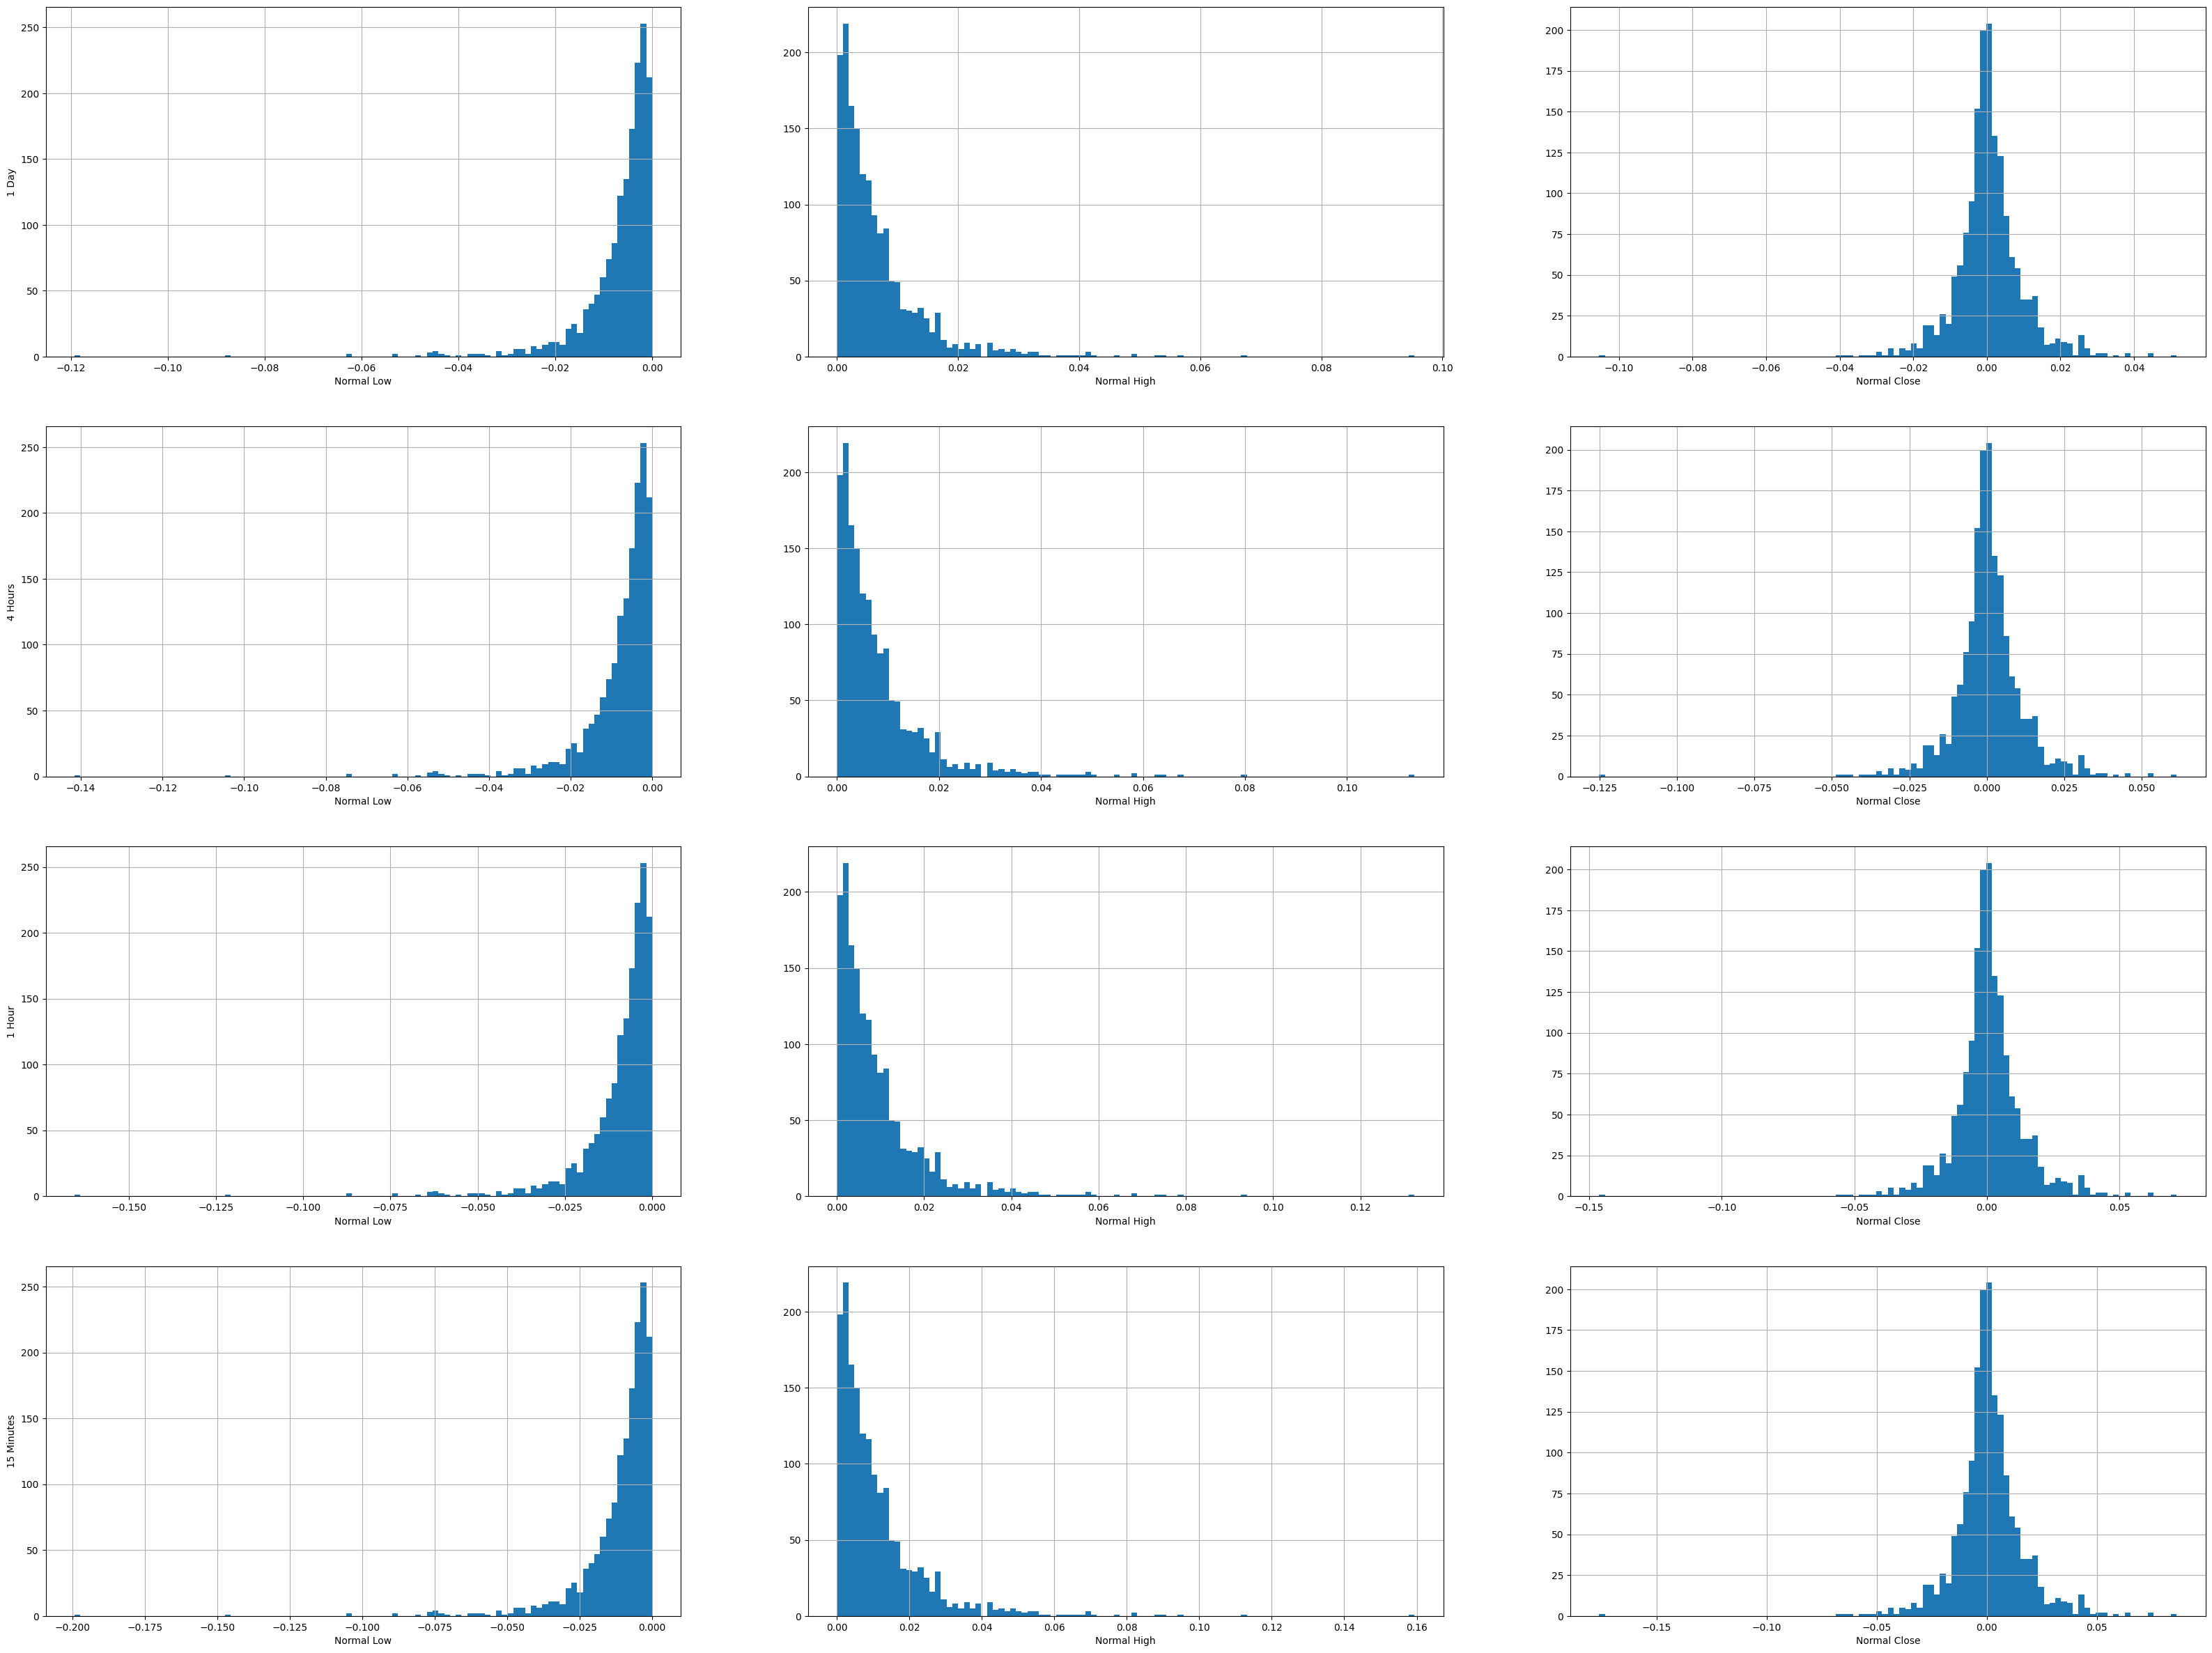

In [40]:
time_frames = [TimeFrame.DAY1, TimeFrame.HOUR4, TimeFrame.HOUR1, TimeFrame.MIN15]


fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(40, 30))
for index, time_frame in enumerate(time_frames):
    df = ONLINE_EXCHANGE.future.data.get_candles_dataframe(symbol=args.symbol, time_frame=args.time_frame)
    
    df["lo"] = df.low / df.open - 1
    df["ho"] = df.high / df.open - 1
    df["co"] = df.close / df.open - 1

    denominator = math.log(time_frame, 20)
    df["normal-low"] = df.lo / denominator
    df["normal-high"] = df.ho / denominator
    df["normal-close"] = df.co / denominator

    print((0.02 <= np.abs(df["normal-low"])).sum() / len(df))
    # print((0.02 <= df["normal-high"]).sum() / len(df))
    # print((0.02 <= df["normal-close"]).sum() / len(df))
    # print()

    # low
    axs[index][0].hist(df["normal-low"], bins=100)
    axs[index][0].set_xlabel("Normal Low")
    axs[index][0].set_ylabel(time_frame)
    axs[index][0].grid()

    # high
    axs[index][1].hist(df["normal-high"], bins=100)
    axs[index][1].set_xlabel("Normal High")
    axs[index][1].grid()

    # close
    axs[index][2].hist(df["normal-close"], bins=100)
    axs[index][2].set_xlabel("Normal Close")
    axs[index][2].grid()

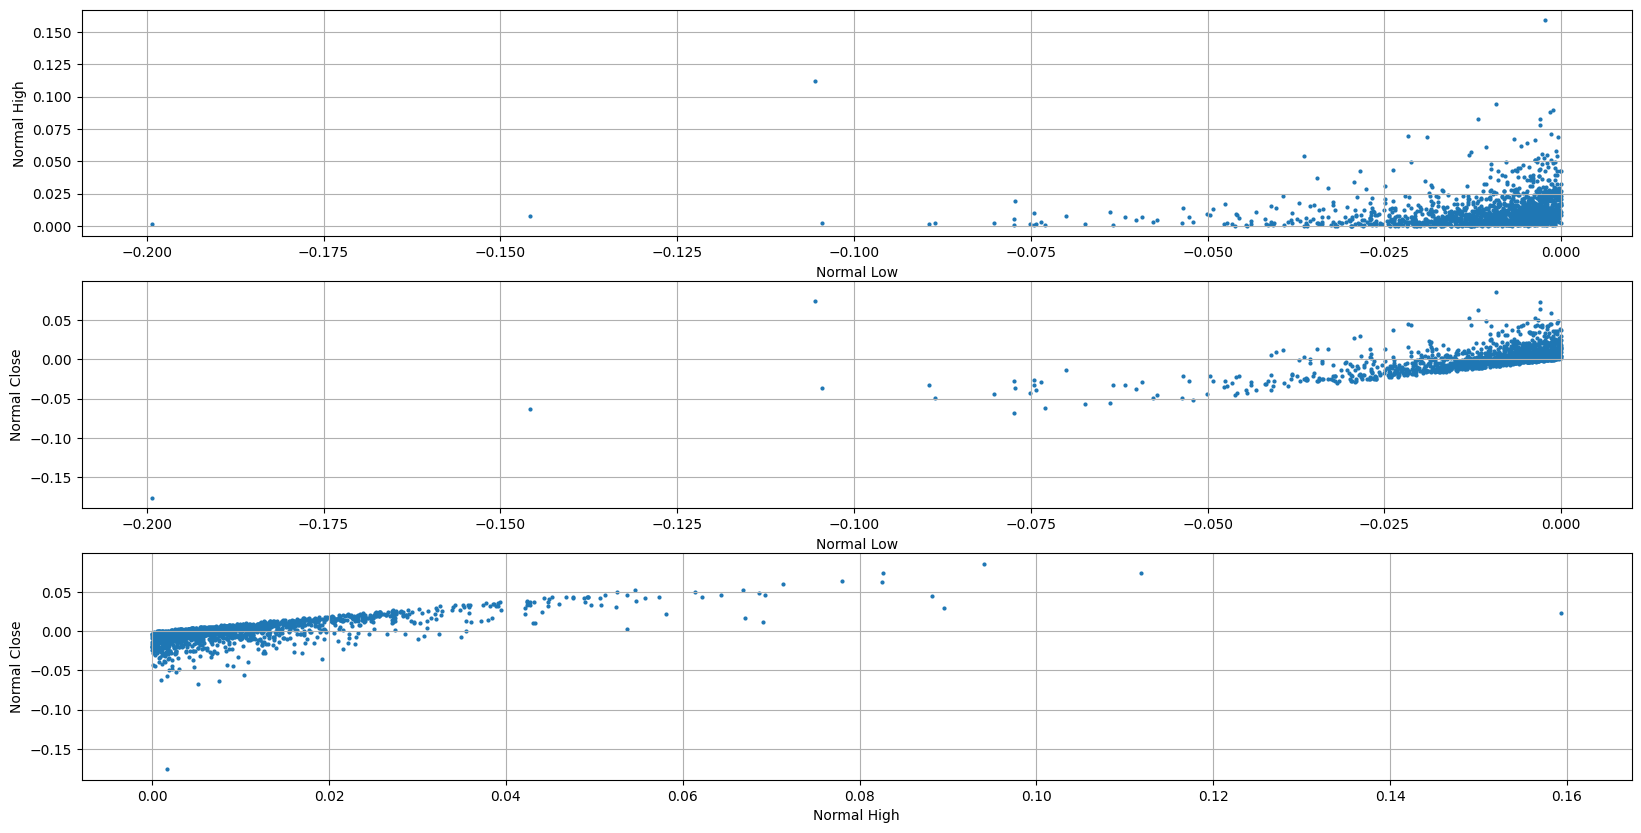

In [43]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(20, 10))

axs[0].scatter(x=df["normal-low"], y=df["normal-high"], s=4)
axs[0].set_xlabel("Normal Low")
axs[0].set_ylabel("Normal High")
axs[0].grid()

axs[1].scatter(x=df["normal-low"], y=df["normal-close"], s=4)
axs[1].set_xlabel("Normal Low")
axs[1].set_ylabel("Normal Close")
axs[1].grid()

axs[2].scatter(x=df["normal-high"], y=df["normal-close"], s=4)
axs[2].set_xlabel("Normal High")
axs[2].set_ylabel("Normal Close")
axs[2].grid()